In [1]:
%matplotlib inline
%precision %.4g

import numpy as np
import scipy as scp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd 

plt.rcParams["text.usetex"] = True

# Parameters and constants

In [2]:
l_ATLAS_run2_1 = 37 #fb^-1
l_ATLAS_run2 = 139 #fb^-1
l_ATLAS_run3 = 300 #fb^-1
l_ATLAS_HL = 3 #ab^-1

alpha_em = 1/137
sw2 = 0.223
cw2 = 1 - sw2

# Conservative parameter choice

In [3]:
#Number of events simulated
n_a = 1.0E6
#List of axion masses simulated, modify accordingly if using a different grid
ma_list = np.logspace(-2,1, num=32)
def ma_to_name(ma):
    """Convert an ALP mass (GeV, float) to the filename stub used in data/."""
    return f"{ma:.4f}GeV".replace('.', '_')
ma_name_list = np.array([ma_to_name(x) for x in ma_list])
################################################################################################################
###########Different convention used for the example since that is what I had from previous simulations, remove when running on your data
ma_list = np.logspace(-2,1, num=31, endpoint=False)[1:]
ma_name_list = ['0_01249609GeV','0_01561523GeV','0_01951293GeV','0_02438354GeV','0_0304699GeV','0_03807546GeV',
                '0_04757944GeV','0_05945571GeV','0_0742964GeV','0_09284145GeV','0_11601553GeV','0_14497407GeV',
                '0_18116092GeV','0_22638034GeV','0_28288694GeV','0_35349811GeV','0_44173447GeV','0_55199543GeV',
                '0_68977854GeV','0_86195357GeV','1_07710506GeV','1_34596032GeV','1_68192432GeV','2_10174801GeV',
                '2_62636353GeV','3_28192787GeV','4_10112707GeV','5_12480588GeV','6_40400427GeV','8_00250228GeV']
################################################################################################################
                        
#Cross sections for the masses simulated in fb
xsec_gagg1e2_list = 180*np.ones(56)

#Parameters used in the simulation
temp = pd.read_csv('results/test-params.csv', index_col=0, header=None)
params = temp.values[1:].astype(float)
#Results of the simulation
temp = pd.read_csv('results/test-results_vbf_isolated.csv', index_col=0, header=None)
gagg_list = temp.values[0]
#Sort the array by hand because the runs finished in a different order than were submitted
temp_sorted = temp.reindex(np.append(['g_agg'], ma_name_list))
#Remove results with few events which are due to some noise/bug in the simulation
temp_sorted[temp_sorted<37] = 0.
#Calculate fraction of events that are isolated
n2g_na = temp_sorted.values[1:]/n_a

In [4]:
#Calculate the production cross-section
prod_xsec_pp_a_13TeV_list = np.array([xsec_gagg1e2_list * (x/1.0E-2)**2 for x in gagg_list])
n_a_ATLAS_run2_list = l_ATLAS_run2/1.0E-3 * prod_xsec_pp_a_13TeV_list
n_a_ATLAS_run3_list = l_ATLAS_run3/1.0E-3 * prod_xsec_pp_a_13TeV_list
n_a_ATLAS_HL_list = l_ATLAS_HL/1.0E-6 * prod_xsec_pp_a_13TeV_list

#Cross-section for events that pass the requirements
xsec_2g = np.array([[n2g_na[i,j] * prod_xsec_pp_a_13TeV_list[j,i] for i in range(len(ma_list))] for j in range(len(gagg_list))])

In [5]:
#Quick function to convert from fraction to total number of events isolated
def n2g (n2g_na, na):
    rslt = n2g_na * na
    return rslt

n2g_run2 = np.array([[n2g(n2g_na[i, j], n_a_ATLAS_run2_list[j, i]) for i in range(len(ma_list))] for j in range(len(gagg_list))])
n2g_run3 = np.array([[n2g(n2g_na[i, j], n_a_ATLAS_run3_list[j, i]) for i in range(len(ma_list))] for j in range(len(gagg_list))])
n2g_HL = np.array([[n2g(n2g_na[i, j], n_a_ATLAS_HL_list[j, i]) for i in range(len(ma_list))] for j in range(len(gagg_list))])

# Compare with existing bounds

In [6]:
temp = pd.read_csv('existing_constraints/Beam_dump.csv', header=None)
ma_beam_dump = temp.T.values[0]
gag_beam_dump = temp.T.values[1]
temp = pd.read_csv('existing_constraints/LEP.csv', header=None)
ma_LEP = temp.T.values[0]
gag_LEP = temp.T.values[1]
#LEP Z --> gamma gamma bound with hypercharge coupling
temp = pd.read_csv('existing_constraints/LEP_aBB.csv', header=None)
ma_LEP_aBB = temp.T.values[0]*1.0E-9
gag_LEP_aBB = temp.T.values[1]*cw2
#LEP Z --> gamma + inv with hypercharge coupling (1709.00009)
temp = pd.read_csv('existing_constraints/Z_gamma_inv_aBB.csv', header=None)
ma_Zginv_aBB = temp.T.values[0]
gag_Zginv_aBB = temp.T.values[1]
temp = pd.read_csv('existing_constraints/CDF.csv', header=None)
ma_CDF = temp.T.values[0]
gag_CDF = temp.T.values[1]
temp = pd.read_csv('existing_constraints/PrimEx.csv', header=None)
ma_PrimEx = temp.T.values[0]
gag_PrimEx = temp.T.values[1]
temp = pd.read_csv('existing_constraints/Belle-II.txt', delim_whitespace=True)
ma_BelleII = temp.T.values[0]
gag_BelleII = temp.T.values[2]
temp = pd.read_csv('existing_constraints/Belle-II_prospects.csv', header=None)
ma_BelleII_pr = temp.T.values[0]
gag_BelleII_pr = temp.T.values[1]
temp = pd.read_csv('existing_constraints/PbPb_ATLAS.csv', header=None)
ma_PbPb_ATLAS = temp.T.values[0]
gag_PbPb_ATLAS = temp.T.values[1]
temp = pd.read_csv('existing_constraints/PbPb_CMS.csv', header=None)
ma_PbPb_CMS = temp.T.values[0]
gag_PbPb_CMS = temp.T.values[1]
temp = pd.read_csv('existing_constraints/LHC.csv', header=None)
ma_LHC = temp.T.values[0]
gag_LHC = temp.T.values[1]
temp = pd.read_csv('existing_constraints/NA64.csv', header=None)
ma_NA64 = temp.T.values[0]
gag_NA64 = temp.T.values[1]
temp = pd.read_csv('existing_constraints/ALPTraum.csv', header=None)
ma_ALPtraum = temp.T.values[0]
gag_ALPtraum = temp.T.values[1]

/var/folders/f3/wq_89gqn6h78djj25gd8rbqm0000gp/T/ipykernel_57963/1605480167.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  temp = pd.read_csv('existing_constraints/Belle-II.txt', delim_whitespace=True)


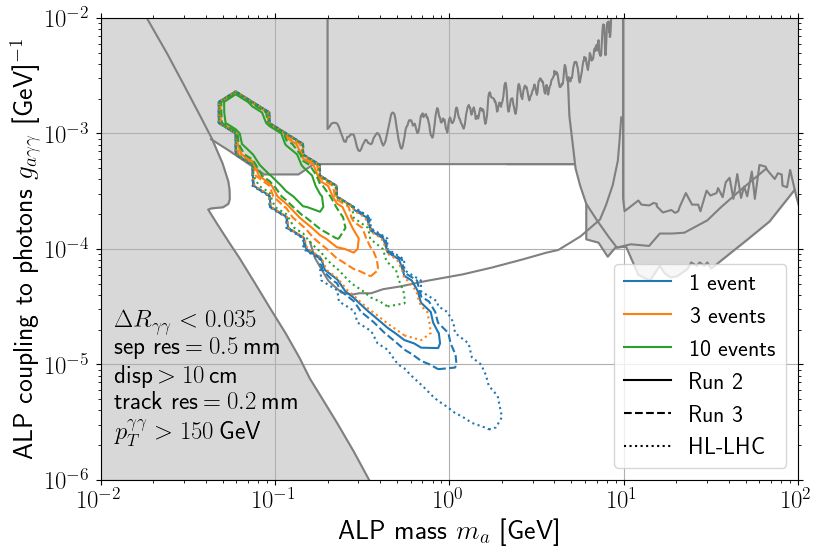

In [7]:
MA, GAGG = np.meshgrid(ma_list, gagg_list)
#Plot
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(111)

ax1.set_xlim([1.0E-2, 1.0E2])
ax1.set_ylim([1.0E-6, 1.0E-2])
ax1.set_xscale('log')
ax1.set_yscale('log')

#Existing constraints
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, [1.0E-2 for x in ma_LEP_aBB], color='w', alpha=1)
ax1.fill_between(ma_LEP_aBB, gag_LEP_aBB, [1.0E-2 for x in ma_LEP_aBB], color='gray', alpha=0.3)
ax1.plot(np.insert(np.insert(ma_LEP_aBB[3:-10], 0, 4.3E-2), -1, 5.2), 
         np.insert(np.insert(gag_LEP_aBB[3:-10], 0, 8.9E-4), -1, gag_LEP_aBB[-10]), c='gray')
ax1.fill_between(ma_CDF, 1.0E-3*gag_CDF, [1.0E-2 for x in ma_CDF], color='w', alpha=1)
ax1.fill_between(ma_CDF, 1.0E-3*gag_CDF, [1.0E-2 for x in ma_CDF], color='gray', alpha=0.3)
ax1.plot(ma_CDF, 1.0E-3*gag_CDF, c='gray')
ax1.fill_between(ma_PbPb_ATLAS, 1.0E-3*gag_PbPb_ATLAS, [1.0E-2 for x in ma_PbPb_ATLAS], color='w', alpha=1)
ax1.fill_between(ma_PbPb_ATLAS, 1.0E-3*gag_PbPb_ATLAS, [1.0E-2 for x in ma_PbPb_ATLAS], color='gray', alpha=0.3)
ax1.plot(ma_PbPb_ATLAS, 1.0E-3*gag_PbPb_ATLAS, c='gray')
ax1.fill_between(ma_PbPb_CMS, 1.0E-3*gag_PbPb_CMS, [1.0E-2 for x in ma_PbPb_CMS], color='w', alpha=1)
ax1.fill_between(ma_PbPb_CMS, 1.0E-3*gag_PbPb_CMS, [1.0E-2 for x in ma_PbPb_CMS], color='gray', alpha=0.3)
ax1.plot(ma_PbPb_CMS[1:], 1.0E-3*gag_PbPb_CMS[1:], c='gray')
ax1.fill_between(ma_LHC, 1.0E-3*gag_LHC, [1.0E-2 for x in ma_LHC], color='w', alpha=1)
ax1.fill_between(ma_LHC, 1.0E-3*gag_LHC, [1.0E-2 for x in ma_LHC], color='gray', alpha=0.3)
ax1.plot(ma_LHC, 1.0E-3*gag_LHC, c='gray')
ax1.fill_between(ma_BelleII, gag_BelleII, [1.0E-2 for x in ma_BelleII], color='w', alpha=1)
ax1.fill_between(ma_BelleII, gag_BelleII, [1.0E-2 for x in ma_BelleII], color='gray', alpha=0.3)
ax1.plot(ma_BelleII, gag_BelleII, c='gray')
ax1.plot(ma_BelleII_pr, gag_BelleII_pr, c='gray')
ax1.fill_betweenx(gag_NA64, ma_NA64, [1.0E-2 for x in ma_NA64], color='w', alpha=1.)
ax1.fill_betweenx(gag_NA64, ma_NA64, [1.0E-2 for x in ma_NA64], color='gray', alpha=0.3)
ax1.plot(ma_NA64, gag_NA64, c='gray')

#levs = [1., 3., 10.]
levs = np.array([0.1, 3., 10.]) #l_ATLAS_run2/l_ATLAS_run3
#Run2
cs = ax1.contour(MA, GAGG, n2g_run2, levels=levs, colors=['C0', 'C1', 'C2', 'C3'], linestyles=['-'], alpha=1.)
#Run3
cs = ax1.contour(MA, GAGG, n2g_run3, levels=levs, colors=['C0', 'C1', 'C2', 'C3'], linestyles=['--'], alpha=1.)
#HL-LHC
cs = ax1.contour(MA, GAGG, n2g_HL, levels=levs, colors=['C0', 'C1', 'C2', 'C3'], linestyles=[':'], alpha=1.)

ax1.plot(0.1,0.1, c='C0', label=r'1 event')
ax1.plot(0.1,0.1, c='C1', label=r'3 events')
ax1.plot(0.1,0.1, c='C2', label=r'10 events')
ax1.plot(0.1,0.1, c='k', ls='-', label=r'Run 2')
ax1.plot(0.1,0.1, c='k', ls='--', label=r'Run 3')
ax1.plot(0.1,0.1, c='k', ls=':', label=r'HL-LHC')

ax1.text(1.2E-2, 2.3E-6, r'$p_T^{{\gamma\gamma}}>{0:.0f}\,$GeV'.format(params[0][0]), fontsize=18)
ax1.text(1.2E-2, 4.2E-6, r'track res$\,={}\,$mm'.format(params[1][0]*1000), fontsize=18)
ax1.text(1.2E-2, 7.0E-6, r'disp$\,>{0:.0f}\,$cm'.format(params[3][0]*100), fontsize=18)
ax1.text(1.2E-2, 1.25E-5, r'sep res$\,={}\,$mm'.format(params[2][0]*1000), fontsize=18)
ax1.text(1.2E-2, 2.1E-5, r'$\Delta R_{{\gamma\gamma}}<{0:.3f}$'.format(params[4][0]), fontsize=18)

ax1.set_xlabel(r'ALP mass $m_a$ [GeV]', fontsize=20)
ax1.set_ylabel(r'ALP coupling to photons $g_{a\gamma\gamma}$ [GeV]$^{-1}$', fontsize=20)
ax1.tick_params(axis='both', left=True, right=True, top=True, bottom=True, which='both', labelsize=18)
ax1.grid()
ax1.legend(loc='lower right', fontsize=17, ncol=1)

#plt.savefig('results/paramer_space.pdf', format='pdf', dpi=1200, bbox_inches='tight')